# Week 5 - Many Strikes, Many Adjustments

## Part 1: Many In, One Out % Loud Channel(1b)

In [238]:
import numpy as np

In [239]:
def w_sum(a, b, debug = False):
    output = 0
    assert len(a) == len(b)
    if len(a) == len(b):
        for i in range(len(a)):
            output += a[i] * b[i]
        if debug:
            print(f"Output: {output}\tLength: {len(a)}")
    else:
        if debug:
            print(f"Length of inputs do not match. Length A:{len(a)}\tLength B:{len(b)}")
    return output



w_sum function brought in from week 2.

In [240]:
def ele_mul(scalar, vector, debug = False):
    output = [0] * len(vector)
    if debug:
        print(f"Length of vector: {len(vector)}")
    for i in range(len(vector)):
        output[i] = scalar *  vector[i]

    return output

Element-wise multiplication getting multiple deltas from multiple weights

In [241]:
def normalize(channel):
    max_value = max(channel)
    result_array = []
    for i in channel:
        result_array.append(i/max_value)

    return result_array

normalize is turning an array of values into a range between 0 and 1. This allows for testing with slightly higher learning rates and not diverging off.

In [242]:
def gradient_descent_multi(input, weights, true, alpha, iterations, debug = False):
    error_result = []
    weight_hist_result = []
    weights_copy = weights.copy()
    for iter in range(0, iterations):
        # Predict
        pred = w_sum(input, weights_copy)

        # Compare and get error
        error = (pred - true) ** 2
        error_result.append(error)
        delta = pred - true

        # Learn
        weight_deltas = ele_mul(delta, input)

        for i in range(len(weight_deltas)):
            weights_copy[i] -= alpha * weight_deltas[i]
        weight_hist_result.append(weights_copy.copy())

        if debug:
            print(f"Iter: {iter+1}\tPred: {pred}\tError: {error:.6f}\tWeights: {weights}")

    return weights_copy, error_result, weight_hist_result



Our normal gradient descent, this time with multiple weights being tuned on a single input. Same predict, compare, learn loop as before.

In [243]:
input = [8.5, 0.65, 1.2]
weights = [0.1, 0.2, -0.1]
true = 1
alpha = 0.01
weights, _, _ = gradient_descent_multi(input, weights, true, alpha, 4, debug = True)

Iter: 1	Pred: 0.8600000000000001	Error: 0.019600	Weights: [0.1, 0.2, -0.1]
Iter: 2	Pred: 0.9637574999999999	Error: 0.001314	Weights: [0.1, 0.2, -0.1]
Iter: 3	Pred: 0.9906177228125002	Error: 0.000088	Weights: [0.1, 0.2, -0.1]
Iter: 4	Pred: 0.997571162993086	Error: 0.000006	Weights: [0.1, 0.2, -0.1]


In the block above, without using normalize, with an alpha of 0.01, we achieve a fairly quick high prediction with very few iterations.
Whereas in the block below, we normalized the inputs and reran with a higher alpha, and only after 20 iterations did we get anywhere close to the same prediction value.
Both however, did not diverge.

In [244]:
input = [8.5, 0.65, 1.2]
weights = [0.1, 0.2, -0.1]
true = 1
alpha = 0.2
print(f"Scaled with alpha {alpha}")
new_input = normalize(input)
weights, _, _ = gradient_descent_multi(new_input, weights, true, alpha, 20, debug = True)

Scaled with alpha 0.2
Iter: 1	Pred: 0.1011764705882353	Error: 0.807884	Weights: [0.1, 0.2, -0.1]
Iter: 2	Pred: 0.2855752493384897	Error: 0.510403	Weights: [0.1, 0.2, -0.1]
Iter: 3	Pred: 0.4321435658323338	Error: 0.322461	Weights: [0.1, 0.2, -0.1]
Iter: 4	Pred: 0.5486425553887384	Error: 0.203724	Weights: [0.1, 0.2, -0.1]
Iter: 5	Pred: 0.6412411121050072	Error: 0.128708	Weights: [0.1, 0.2, -0.1]
Iter: 6	Pred: 0.7148425462340526	Error: 0.081315	Weights: [0.1, 0.2, -0.1]
Iter: 7	Pred: 0.773344225935724	Error: 0.051373	Weights: [0.1, 0.2, -0.1]
Iter: 8	Pred: 0.8198439520404678	Error: 0.032456	Weights: [0.1, 0.2, -0.1]
Iter: 9	Pred: 0.8568039938519579	Error: 0.020505	Weights: [0.1, 0.2, -0.1]
Iter: 10	Pred: 0.886181472068281	Error: 0.012955	Weights: [0.1, 0.2, -0.1]
Iter: 11	Pred: 0.9095319929024389	Error: 0.008184	Weights: [0.1, 0.2, -0.1]
Iter: 12	Pred: 0.9280920210713468	Error: 0.005171	Weights: [0.1, 0.2, -0.1]
Iter: 13	Pred: 0.9428443534958446	Error: 0.003267	Weights: [0.1, 0.2, -0.1]
I

## Numpy Version

In [245]:
def gradient_descent_multi_numpy(input, weights, true, alpha, iterations, debug = False):
    np_error_result = []
    np_weight_hist_result = []
    np_input = np.array(input)
    np_weights = np.array(weights)

    for iter in range(0,iterations):

        # Predict
        pred = np_input.dot(np_weights.T)

        # Compare and get error
        error = (pred - true) ** 2
        np_error_result.append(error)
        deltas = pred - true

        # Learn
        # print((alpha * np.outer(deltas,input)).shape) (1,3)
        # print(np_weights.shape) (3,)
        np_weights -= alpha * deltas * np_input
        np_weight_hist_result.append(np_weights.copy())

        if debug:
            print(f"Iter: {iter+1}\tPred: {pred}\tError: {error:.6f}\tWeights: {np_weights}")

    return np_weights, np_error_result, np_weight_hist_result

## Part 2: One In, Many Out

In this section we go from one output, to many outputs.

In [246]:
def gradient_descent_outputs(input, weights, trues, alpha, iterations, debug = False):
    error_result = []
    weight_hist_result = []
    weights_copy = weights.copy()
    for iter in range(0, iterations):
        # Predict
        preds = [input * w for w in weights_copy]

        # Compare and get error
        deltas = [preds[i] - trues[i] for i in range(len(weights_copy))]
        errors = [d ** 2 for d in deltas]
        mse = sum(errors) / len(errors)
        error_result.append(mse)

        # Learn
        weighted_deltas = [d * input for d in deltas]
        for i in range(len(weights_copy)):
            weights_copy[i] -= alpha * weighted_deltas[i]

        weight_hist_result.append(weights_copy.copy())

        if debug:
            print(f"Iter: {iter+1}\tPred: {preds}\n\tError: {errors}\n\tWeights: {weights_copy}\n\tMSE: {mse}")

    return weights_copy, error_result, weight_hist_result

In [247]:
input = 0.65
weights = [0.3, 0.2, 0.9]
trues = [0.0, 1.0, 0.0]
alpha = 0.1
iterations = 10

weights, _, _ = gradient_descent_outputs(input, weights, trues, alpha, iterations, debug = True)

Iter: 1	Pred: [0.195, 0.13, 0.5850000000000001]
	Error: [0.038025, 0.7569, 0.3422250000000001]
	Weights: [0.287325, 0.25655, 0.861975]
	MSE: 0.37905000000000005
Iter: 2	Pred: [0.18676125000000002, 0.1667575, 0.5602837500000001]
	Error: [0.03487976450156251, 0.69429306380625, 0.3139178805140626]
	Weights: [0.27518551874999997, 0.3107107625, 0.82555655625]
	MSE: 0.347696902940625
Iter: 3	Pred: [0.17887058718749999, 0.20196199562500003, 0.5366117615625]
	Error: [0.03199468696080104, 0.6368646564268324, 0.28795218264720934]
	Weights: [0.2635589305828125, 0.362583232784375, 0.7906767917484375]
	MSE: 0.3189371753449476
Iter: 4	Pred: [0.17131330487882812, 0.23567910130984374, 0.5139399146364844]
	Error: [0.029348248428506314, 0.5841864361745281, 0.2641342358565568]
	Weights: [0.25242356576568864, 0.4122640911992351, 0.7572706972970661]
	MSE: 0.2925563068198638
Iter: 5	Pred: [0.16407531774769762, 0.26797165927950284, 0.492225953243093]
	Error: [0.026920709894007938, 0.5358654916180042, 0.24228

In the above section, we now see that there are multiple predictions being made, not just the singular one.

In [248]:
## Numpy Version

In [249]:
def gradient_descent_outputs_numpy(input, weights, trues, alpha, iterations, debug = False):
    error_result = []
    weight_hist_result = []
    np_input = np.asarray(np.float64(input))
    weights_copy = weights.copy()
    for iter in range(0, iterations):
        # Predict
        preds = np_input * weights_copy

        # Compare and get error
        deltas = preds - trues
        errors = [d ** 2 for d in deltas]
        mse = np.mean(errors)
        error_result.append(mse)

        # Learn
        weights_copy -= alpha * deltas * np_input
        weight_hist_result.append(weights_copy.copy())

        if debug:
            print(f"Iter: {iter+1}\tPred: {preds}\n\tError: {errors}\n\tWeights: {weights_copy}\n\tMSE: {mse}")

    return weights_copy, error_result, weight_hist_result

## Part 3: Many In, Many Out

In this section we now put it all together and have multiple weights, multiple predictions.

In [250]:
import copy
def vect_mat_mul(vect, matrix):
    return [w_sum(vect, row, debug=False) for row in matrix]

def outer_product(a, b):
    big_box = [[0]*len(b) for _ in range(len(a))]
    for i in range(len(a)):
        for j in range(len(b)):
            big_box[i][j] = a[i] * b[j]

    return big_box

def get_deltas(preds, trues):
        assert len(preds) == len(trues)
        deltas = [0]*len(preds)
        for i in range(len(preds)):
            deltas[i]=preds[i]-trues[i]
        return deltas

def calc_mse(deltas):
    sq_sum = 0
    for i in range(len(deltas)):
        sq_sum += deltas[i]**2
    sq_sum /= len(deltas)
    return sq_sum

Above are some helpers while the full implementation is below. This will be returning multiple predictions from multiple sets of weights.

In [251]:
def gradient_descent_full(input, weights, trues, alpha, iterations):

    # kind of irrelevant
    cur_weights = weights

    # make a big box to hold all our weights for each iteration; 1 more slot than there are iterations,
    # to store starting state as well
    weights_history = [[[0]*len(weights[0]) for _ in range(len(weights))] for _ in range(iterations+1)]
    # make a copy of weights and stick it in slot 0
    weights_history[0] = copy.deepcopy(weights)

    # same deal for error history
    error_history = [0]*(iterations+1)

    # as many times as we have iterations...
    for iter in range(iterations):
        # calculate predictions...
        preds = vect_mat_mul(input, cur_weights)

        # find the difference between the predictions and reality...
        deltas = get_deltas(preds, trues)

        # calculate the error and store it...
        error = calc_mse(deltas)
        # appends error before the modification of the weights,
        # so it catches the initial error and misses the last error.
        # We append the last error after the loop.
        error_history[iter] = error

        # create the outer product of our deltas and our inputs...
        weight_deltas = outer_product(deltas, input)

        # and modify our weights by that amount.
        for i in range(len(cur_weights)):
            for j in range(len(cur_weights[0])):
                cur_weights[i][j] -= alpha*weight_deltas[i][j]

        #(And also save those weights after modification.)
        weights_history[iter+1] = copy.deepcopy(cur_weights)

    # run one more pass and save its error too!
    preds = vect_mat_mul(input, cur_weights)
    error_history[-1]=calc_mse(get_deltas(vect_mat_mul(input, cur_weights), trues))

    return cur_weights, error_history, weights_history

In [252]:
## Numpy Version

In [253]:
def grad_desc_numpy_full(input, weights, trues, alpha, iterations):
    cur_weights = np.array(weights)
    np_trues = np.array(trues)
    np_input = np.array(input)
    weights_history = np.empty((iterations+1, *cur_weights.shape))
    error_history = np.empty(iterations+1)
    for iter in range(iterations):
        # save weights before modification; so we'll need to do it one more time at the end
        weights_history[iter] = cur_weights

        preds = cur_weights@np_input
        deltas = preds - np_trues
        mse = np.mean(deltas**2)
        # same deal, save error before modification
        error_history[iter] = mse

        weight_deltas = np.outer(deltas, np_input)

        cur_weights -= alpha * weight_deltas


    # save final weights
    weights_history[-1] = cur_weights
    # one last pass to find final error, then save it
    error_history[-1]=np.mean(((cur_weights@np_input)-np_trues)**2)

    return cur_weights, error_history, weights_history

This runs a comparison between the two versions to ensure they match logically.

In [254]:
final_weights, errors, weights_history = gradient_descent_full(input = [8.5, 0.65, 1.2], weights = [[0.1, 0.1, -0.3], [0.1, 0.2, 0.0], [0.0, 1.3, 0.1]],
        trues = [0.0, 1.0, 0.1], alpha = 0.01, iterations = 15)

# –- NumPy version –-
np_weights, np_errors, np_weight_history = grad_desc_numpy_full(input = [8.5, 0.65, 1.2], weights = [[0.1, 0.1, -0.3], [0.1, 0.2, 0.0], [0.0, 1.3, 0.1]],
    trues = [0.0, 1.0, 0.1], alpha = 0.01, iterations = 15)

if (np.allclose(np.array(final_weights), np_weights)):
    print("Numpy version and from scratch version agree on final weights!")
if (np.allclose(np.array(errors), np_errors)):
    print("Numpy version and from scratch version agree on error history!")
if (np.allclose(np.array(weights_history), np_weight_history)):
    print("Numpy version and from scratch version agree on weight history!")

Numpy version and from scratch version agree on final weights!
Numpy version and from scratch version agree on error history!
Numpy version and from scratch version agree on weight history!


## Part 4: Freezing the Inner Gaze

Quick helper function

In [255]:
def calc_error(delta):
    return delta**2

In this section, we are adding in freezing weights to allow the other weights to train and change. So some weights will stay the same, forcing the other ones to adapt more since not all are adjusting anymore.

In [256]:
def gradient_descent_frozen(input, weights, true, alpha, iterations, frozen):
    # pred = input w_sum weights, delta = pred - true, error = delta**2,
    # weights_deltas = inputs * delta for non-frozen weights
    # weights = weights - weights_deltas*alpha

    # kinda irrelevant
    cur_weights = weights

    # make the boxes that will hold our past errors and weights.
    # they have size iterations+1 to store the initial state too,
    # e.g. 4 iterations = 5 errors to store including the starting error
    error_history = [0]*(iterations+1)
    # this one is a multi-dimensional box since it'll be storing weight vectors
    weights_history = [[0]*len(weights) for _ in range(iterations+1)]

    # as many times as we're supposed to...
    for iter in range(iterations):
        #store our weights before this iteration...
        weights_history[iter] = copy.deepcopy(cur_weights)

        # run a forward pass...
        pred = w_sum(input, cur_weights)

        # find the difference between that prediction and the truth...
        delta = pred - true

        # calculate the error from that and save it...
        error_history[iter] = calc_error(delta)

        # calculate how much we want to change each weight...
        weight_deltas = ele_mul(delta, input)

        # obliterate all such changes for frozen weights...
        for i in range(len(frozen)):
            # for all values in frozen, set the corresponding spot
            # in weight_deltas to 0, so we won't update in the next loop
            weight_deltas[frozen[i]] = 0

        # and subtract our (post-freezing) weight modifications!
        for i in range(len(cur_weights)):
            # (scaled by alpha, of course)
            cur_weights[i] -= alpha*weight_deltas[i]

    # don't forget to save our final weights, since we normally do so at
    # the start of the loop and it won't loop back one final time!
    weights_history[-1] = copy.deepcopy(cur_weights)
    # run a forward pass here to check the final error too
    error_history[-1] = calc_error(w_sum(input, cur_weights) - true)
    return cur_weights, error_history, weights_history

weights_one, err_hist_one, weight_hist_one = gradient_descent_frozen([8.5, 0.65, 1.2], [0.1, 0.2, -0.1], 1.0, 0.01, 5, [])
print(f"First one, final weights are:\n{weights_one}\nError history is:\n{err_hist_one}\nAnd full weight history is:\n{weight_hist_one}")
weights_two, err_hist_two, weight_hist_two = gradient_descent_frozen([8.5, 0.65, 1.2], [0.1, 0.2, -0.1], 1.0, 0.3, 5, [0, 2])
print(f"\n\nSecond one, final weights are:\n{weights_two}\nError history is:\n{err_hist_two}\nAnd full weight history is:\n{weight_hist_two}")
weights_three, err_hist_three, weight_hist_three = gradient_descent_frozen([8.5, 0.65, 1.2], [0.1, 0.2, -0.1], 1.0, 0.3, 5, [0, 1])
print(f"\n\nThird one, final weights are:\n{weights_three}\nError history is:\n{err_hist_three}\nAnd full weight history is:\n{weight_hist_three}")


First one, final weights are:
[0.1160380022468392, 0.2012264354659348, -0.09773581144750507]
Error history is:
[0.01959999999999997, 0.0013135188062500048, 8.802712522307997e-05, 5.899249206154892e-06, 3.953456517877471e-07, 2.6494589213863218e-08]
And full weight history is:
[[0.1, 0.2, -0.1], [0.1119, 0.20091, -0.09832], [0.11498061250000001, 0.20114557625, -0.09788509000000001], [0.1157781060609375, 0.20120656105171877, -0.09777250267375001], [0.11598455720652519, 0.20122234849226373, -0.09774335662966704], [0.1160380022468392, 0.2012264354659348, -0.09773581144750507]]


Second one, final weights are:
[0.1, 0.30601223843384895, -0.1]
Error history is:
[0.01959999999999997, 0.014946285024999973, 0.01139752224737442, 0.008691357963675359, 0.0066277302744589504, 0.00505407886484106]
And full weight history is:
[[0.1, 0.2, -0.1], [0.1, 0.2273, -0.1], [0.1, 0.251139725, -0.1], [0.1, 0.27195776485624995, -0.1], [0.1, 0.29013711816072024, -0.1], [0.1, 0.30601223843384895, -0.1]]


Third o

## Part 5: Watching the Weights

This section pulls together the others to give a graphical display to how the weights change within the learning iterations.

In [257]:
import matplotlib
matplotlib.use("Agg") # render to a file; no display needed
import matplotlib.pyplot as plt
%matplotlib inline

Quick extra imports of matplotlib

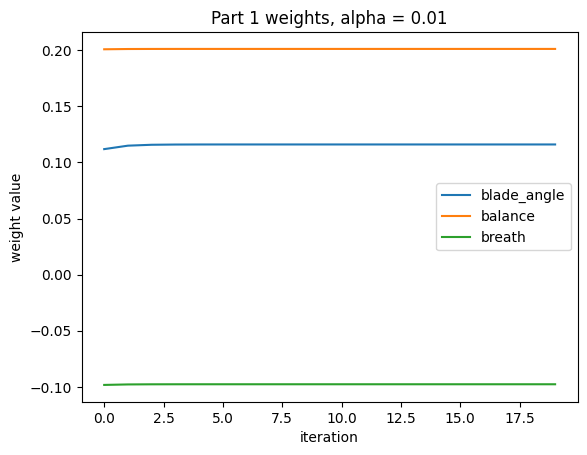

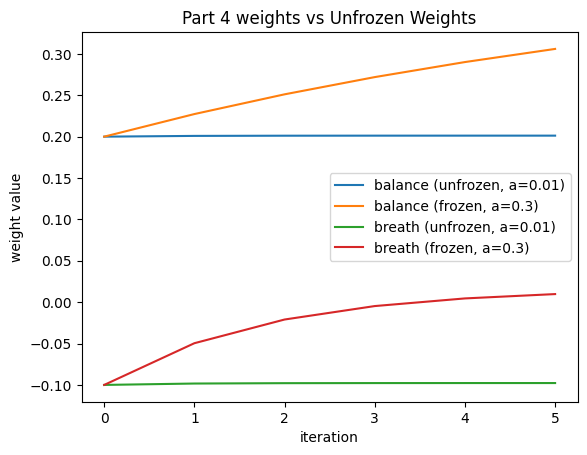

In [258]:
weights, errors, weight_history = gradient_descent_multi(
    [8.5, 0.65, 1.2], [0.1, 0.2, -0.1], 1.0, 0.01, 20)

for j, name in enumerate(["blade_angle", "balance", "breath"]):
    plt.plot([w[j] for w in weight_history], label=name)

plt.xlabel("iteration")
plt.ylabel("weight value")
plt.title("Part 1 weights, alpha = 0.01")
plt.legend()
plt.show()
plt.close()


# PART 4 Plotting
_, _, baseline_history = gradient_descent_frozen(
    [8.5, 0.65, 1.2], [0.1, 0.2, -0.1], 1.0, 0.01, 5, []
    )
_, _, balance_history = gradient_descent_frozen(
    [8.5, 0.65, 1.2], [0.1, 0.2, -0.1], 1.0, 0.3, 5, [0, 2]
    )
_, _, breath_history = gradient_descent_frozen(
    [8.5, 0.65, 1.2], [0.1, 0.2, -0.1], 1.0, 0.3, 5, [0, 1]
    )


plt.plot([w[1] for w in baseline_history], label='balance (unfrozen, a=0.01)')
plt.plot([w[1] for w in balance_history], label='balance (frozen, a=0.3)')
plt.plot([w[2] for w in baseline_history], label='breath (unfrozen, a=0.01)')
plt.plot([w[2] for w in breath_history], label='breath (frozen, a=0.3)')


plt.xlabel("iteration")
plt.ylabel("weight value")
plt.title("Part 4 weights vs Unfrozen Weights")
plt.legend()
plt.show()
plt.close()

1. Free Weight Trajectory (Figure 2):
   Free weights move much faster and steeper because they must absorb all the slack
   and correct the full error alone without help from frozen channels.

2. Steepest Line (Figure 1):
   'blade_angle' is the steepest because its large input (8.5) creates much larger
   updates (delta * input), matching the prediction from Part 1.

3. Flat Lines (Figure 1):
   'balance' and 'breath' look flat because their updates are tiny relative to
   'blade_angle'. They aren't actually flat; to verify, plot each weight on its own
   y-axis scale or use a logarithmic scale.

## Part 6: Unit Tests

### Part 1 Testing

In [259]:
def test_normalization():
    # Normalize an array of inputs
    assert normalize([4, 2, 1]) == [
        1,
        0.5,
        0.25,
    ], "Biggest value (4) should become 1, and the others (2 and 1, half and one-fourth) should be 0.5 and 0.25."

In [260]:
# -- Part 1: Multi-input GD --
def test_multi_in_gd():
    # Setup
    sensing = [1, 1.5, -0.75]
    weights = [1, 0.5, 0.25]
    final_weights, errors, _ = gradient_descent_multi(sensing, weights, 1, 0.1, 10)

    # Error goes down
    for i in range(len(errors) - 2):
        assert errors[i] > errors[i + 1], "Errors should decrease over each iteration"

    # Final prediction is close to goal (which is 1)
    # get prediciton

    final_pred = w_sum(sensing, final_weights)
    assert (
        abs(final_pred - 1) < .01
    ), "Final prediction should be close to the goal for an easy sensing"

In [261]:
def test_multi_in_agreement():
    sensing = [8.5, 0.65, 1.2]
    weights = [0.1, 0.2, -0.1]
    true = 1.0
    alpha = 0.01
    iterations = 10

    final_weights_scratch, _, _ = gradient_descent_multi(
        sensing, weights, true, alpha, iterations
    )
    final_weights_numpy, _, _ = gradient_descent_multi_numpy(
        sensing, weights, np.float64(true), np.float64(alpha), iterations
    )

    pred_scratch = w_sum(sensing, final_weights_scratch)
    pred_numpy = np.asarray(sensing) @ final_weights_numpy.T

    assert (
        abs(pred_scratch - pred_numpy) < 1e-10
    ), "Multi-in Gradient Descent from scratch must be comparable to NumPy equivalent"

### Part 2 Testing

In [262]:
# -- Part 2: Multi-output GD --
def test_multi_out_gd():
    # Use data from recurring dataset
    balance = 0.65
    weights = [0.3, 0.2, 0.9]
    trues = [0.0, 1.0, 0.0]
    _, _, weight_history = gradient_descent_outputs(balance, weights, trues, 0.01, 20)

    # Iterate through weight_history, comparing each value with the next
    # range() is 0-based when given one argument, so subtract 2 from the
    # length so we don't try to compare the last set of weights with a set
    # that doesn't exist
    for i in range(len(weight_history) - 2):
        weighti = weight_history[i]
        weightip = weight_history[i + 1]
        pred = [balance * weight for weight in weighti]
        next_pred = [balance * weight for weight in weightip]

        # Use abs(pred - true) for sheer magnitude, no direction or
        # square exaggerations despite their technical correctness
        deltas = [abs(p - true) for p, true in zip(pred, trues)]
        next_deltas = [abs(p - true) for p, true in zip(next_pred, trues)]

        for i in range(3):
            assert (
                deltas[i] >= next_deltas[i]
            ), "Predictions should be moving toward the target"
            assert (
                weighti[i] == weightip[i]
                if deltas[i] == next_deltas[i]
                and pred[i] == next_pred[i]
                and pred[i] == trues[i]
                else weighti[i] != weightip[i]
            ), "Weight should change each iteration unless the prediction matches the target"

In [263]:
def test_multi_out_agreement():

    balance = 0.65
    weights = [0.3, 0.2, 0.9]
    trues = [0.0, 1.0, 0.0]
    alpha = 0.1
    iterations = 20

    final_weights_scratch, _, _ = gradient_descent_outputs(
        balance, weights, trues, alpha, iterations
    )
    final_weights_numpy, _, _ = gradient_descent_outputs_numpy(
        balance, weights, np.float64(trues), np.float64(alpha), iterations
    )

    preds_scratch = [balance * weight for weight in final_weights_scratch]
    preds_numpy = np.float64(balance) * final_weights_numpy

    assert [
        abs(pred_scratch - pred_numpy) < 1e-10
        for pred_scratch, pred_numpy in zip(preds_scratch, preds_numpy)
    ], "Multi-out Gradient Descent from scratch must be comparable to NumPy equivalent"

### Part 3 Testing

In [264]:
def test_outer_product():
    assert outer_product([1, 2], [3, 4, 5]) == [
        [3, 4, 5],
        [6, 8, 10],
    ], "A len-2 list outer_prod'ed with a len-3 list produces a 2x3 matrix; [1,2]x[3,4,5] == [[3,4,5],[6,8,10]]"
    assert outer_product([6, 7, 8], [9, 10]) == [
        [54, 60],
        [63, 70],
        [72, 80],
    ], "A len-3 list outer_prod'ed with a len-2 list produces a 3x2 matrix; [6,7,8]x[9,10] == [[54,60],[63,70],[72,80]]"

In [265]:
def test_multi_in_out_agreement():

    sensing = [8.5, 0.65, 1.2]
    weights = [[0.1, 0.1, -0.3], [0.1, 0.2, 0.0], [0.0, 1.3, 0.1]]
    trues = [0.0, 1.0, 0.0]
    alpha = 0.01
    iterations = 15

    final_weights_scratch, _, _ = gradient_descent_full(
        sensing, weights, trues, alpha, iterations
    )
    final_weights_numpy, _, _ = grad_desc_numpy_full(
        sensing, weights, trues, np.float64(alpha), iterations
    )

    preds_scratch = vect_mat_mul(sensing, final_weights_scratch)
    preds_numpy = np.asarray(sensing) @ final_weights_numpy.T

    assert [
        abs(pred_scratch - pred_numpy) < 1e-10
        for pred_scratch, pred_numpy in zip(preds_scratch, preds_numpy)
    ], "Multi-in-multi-out Gradient Descent from scratch must be comparable to NumPy equivalent"

### Part 4 Testing

In [266]:
def test_freezing():
    # Test 1: 1 index frozen
    frozen = [2]
    frozen_copy = frozen.copy()
    sensing = [8.5, 0.65, 1.2]
    weights = [0.1, 0.2, -0.1]
    true = 1
    _, _, weight_history = gradient_descent_frozen(
        sensing, weights, true, 0.3, 5, frozen
    )

    # Indices of frozen must not change
    assert frozen == frozen_copy, "Indices of frozen must not change"
    # Iterate through weight_history, comparing each value with the next
    for i in range(len(weight_history) - 1):
        # Setup for checking that free weights change unless they don't need to.
        weighti = weight_history[i]
        weightip = weight_history[i + 1]
        pred = w_sum(sensing, weighti)
        next_pred = w_sum(sensing, weightip)

        # Use abs(pred - true) for sheer magnitude, no direction or
        # square exaggerations despite their technical correctness
        delta = pred - true
        next_delta = next_pred - true

        # The frozen weights must not change
        for j in range(len(weighti) - 1):
            if j in frozen_copy:
                assert (
                    weighti[j] == weightip[j]
                ), "Frozen weights must not change"
            else:
                assert (
                    weighti[j] == weightip[j]
                    if delta == next_delta
                    and pred == next_pred
                    and pred == true
                    else weighti[j] != weightip[j]
                ), "Free weights must change"

    # Test 2: 2 indices frozen
    frozen = [0, 2]
    frozen_copy = frozen.copy()
    sensing = [8.5, 0.65, 1.2]
    weights = [0.1, 0.2, -0.1]
    true = 1
    _, _, weight_history = gradient_descent_frozen(
        sensing, weights, true, 0.3, 5, frozen
    )

    for i in range(len(weight_history) - 1):
        # Setup for checking that free weights change unless they don't need to.
        weighti = weight_history[i]
        weightip = weight_history[i + 1]
        pred = w_sum(sensing, weighti)
        next_pred = w_sum(sensing, weightip)

        # Use abs(pred - true) for sheer magnitude, no direction or
        # square exaggerations despite their technical correctness
        delta = pred - true
        next_delta = next_pred - true

        # The frozen weights must not change
        for j in range(len(weighti) - 1):
            if j in frozen_copy:
                assert (
                    weighti[j] == weightip[j]
                ), "Frozen weights must not change"
            else:
                assert (
                    weighti[j] == weightip[j]
                    if delta == next_delta
                    and pred == next_pred
                    and pred == true
                    else weighti[j] != weightip[j]
                ), "Free weights must change"

## Test results all called after declaration

In [268]:
if __name__ == "__main__":
    tests = [name for name in dir() if name.startswith("test_")]
    for test_name in sorted(tests):
        test_func = globals()[test_name]

        if test_name.startswith("test_") and callable(globals().get(test_name)):
          try:
              test_func()
              print(f" PASS: {test_name}")
          except AssertionError as e:
              print(f" FAIL: {test_name} -- {e}")
          except ImportError as e:
              print(f" FAIL: {test_name} -- {e}")

 PASS: test_freezing
 PASS: test_func
 PASS: test_multi_in_agreement
 PASS: test_multi_in_gd
 PASS: test_multi_in_out_agreement
 PASS: test_multi_out_agreement
 PASS: test_multi_out_gd
 PASS: test_normalization
 PASS: test_outer_product
